In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load all results
df = pd.read_csv("../data/featured_sample.csv")
df['date'] = pd.to_datetime(df['date'])
inventory = pd.read_csv("../data/inventory_optimization.csv")
reorder_schedule = pd.read_csv("../data/reorder_schedule.csv")
revenue_forecast = pd.read_csv("../data/revenue_forecast_30days.csv")

print("All data loaded successfully!")
print("Featured data:", df.shape)
print("Reorder schedule:", reorder_schedule.shape)
print("Revenue forecast:", revenue_forecast.shape)

All data loaded successfully!
Featured data: (500000, 32)
Reorder schedule: (15245, 18)
Revenue forecast: (3, 5)


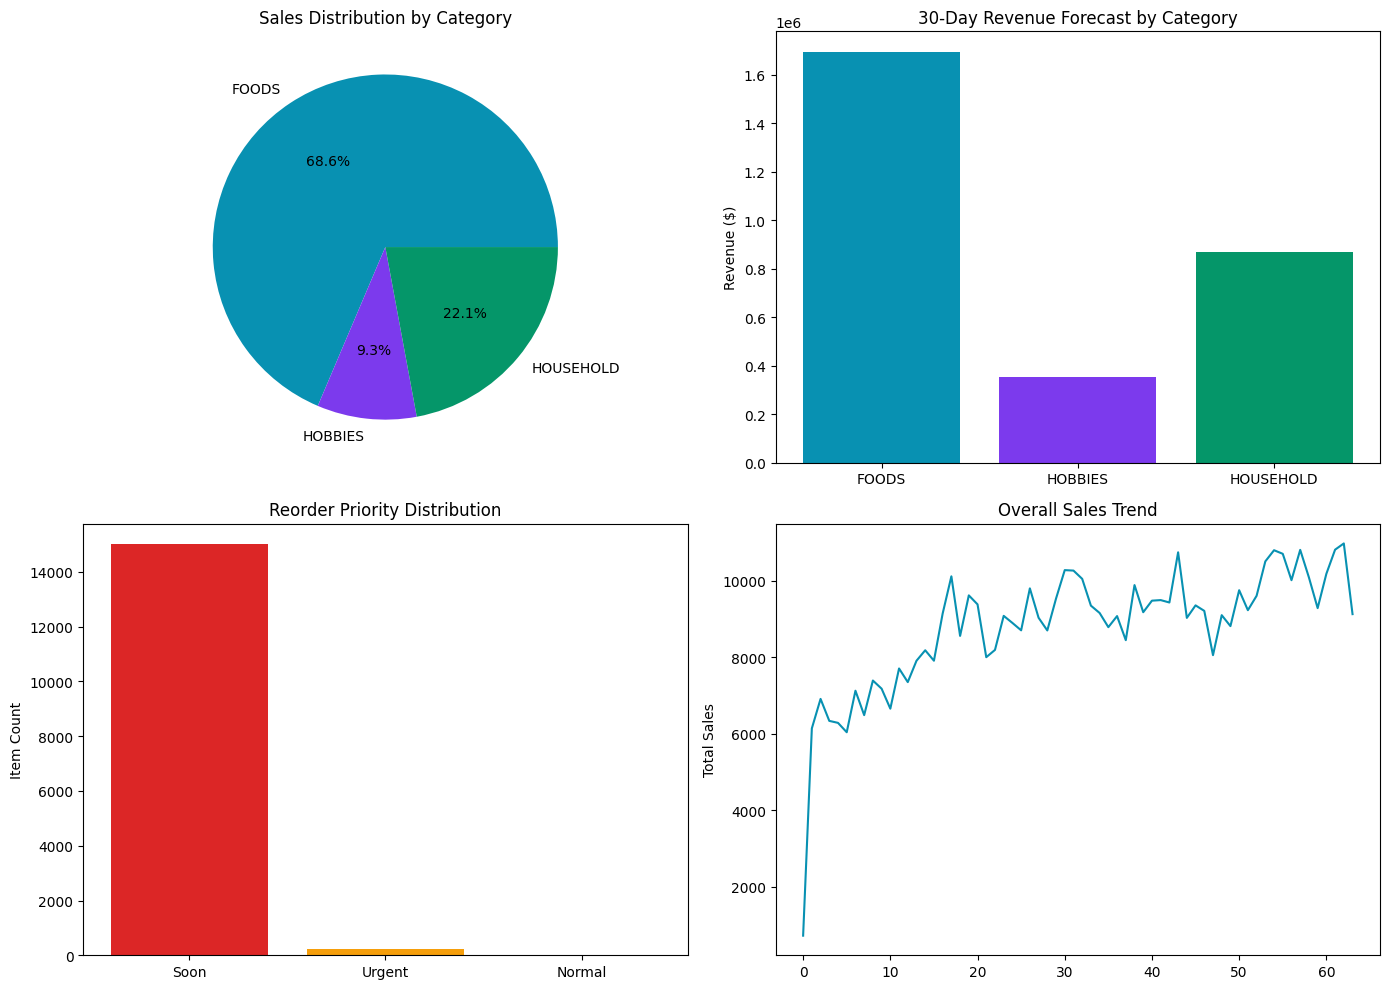

Final visualizations created!


In [2]:
# Final Summary Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Sales by category
cat_sales = df.groupby('cat_id')['sales'].sum()
axes[0,0].pie(cat_sales.values, labels=cat_sales.index, autopct='%1.1f%%',
              colors=['#0891B2', '#7C3AED', '#059669'])
axes[0,0].set_title("Sales Distribution by Category")

# 2. Revenue forecast by category
axes[0,1].bar(revenue_forecast['cat_id'], revenue_forecast['total_monthly_revenue'],
              color=['#0891B2', '#7C3AED', '#059669'])
axes[0,1].set_title("30-Day Revenue Forecast by Category")
axes[0,1].set_ylabel("Revenue ($)")

# 3. Reorder priority distribution
priority_counts = reorder_schedule['priority'].value_counts()
axes[1,0].bar(priority_counts.index, priority_counts.values,
              color=['#DC2626', '#F59E0B', '#059669'])
axes[1,0].set_title("Reorder Priority Distribution")
axes[1,0].set_ylabel("Item Count")

# 4. Sales trend
monthly = df.groupby(['year','month'])['sales'].sum().reset_index()
axes[1,1].plot(range(len(monthly)), monthly['sales'], color='#0891B2')
axes[1,1].set_title("Overall Sales Trend")
axes[1,1].set_ylabel("Total Sales")

plt.tight_layout()
plt.show()

print("Final visualizations created!")

In [3]:
# Complete Project Summary Statistics
print("="*60)
print("PROJECT 3 - COMPLETE SUMMARY STATISTICS")
print("="*60)

print(f"\nTotal Items Analyzed: {df['item_id'].nunique():,}")
print(f"Total Stores: {df['store_id'].nunique()}")
print(f"Total States: {df['state_id'].nunique()}")
print(f"Total Categories: {df['cat_id'].nunique()}")
print(f"Date Range: {df['date'].min().date()} to {df['date'].max().date()}")

print(f"\nTotal Sales Analyzed: {df['sales'].sum():,.0f} units")
print(f"Average Daily Sales: {df.groupby('date')['sales'].sum().mean():,.0f} units")

print(f"\nInventory Items Optimized: {len(inventory):,}")
print(f"Items Needing Urgent Reorder: {(reorder_schedule['priority']=='Urgent').sum()}")

print(f"\nTotal 30-Day Revenue Forecast: ${revenue_forecast['total_monthly_revenue'].sum():,.2f}")

print("="*60)

PROJECT 3 - COMPLETE SUMMARY STATISTICS

Total Items Analyzed: 3,049
Total Stores: 10
Total States: 3
Total Categories: 3
Date Range: 2011-01-29 to 2016-04-24

Total Sales Analyzed: 562,161 units
Average Daily Sales: 294 units

Inventory Items Optimized: 30,490
Items Needing Urgent Reorder: 224

Total 30-Day Revenue Forecast: $2,917,079.15


In [ ]:
# Save final project summary
final_summary = {
    "total_items_optimized": len(inventory),
    "total_stores": df['store_id'].nunique(),
    "total_states": df['state_id'].nunique(),
    "total_categories": df['cat_id'].nunique(),
    "urgent_reorders": int((reorder_schedule['priority']=='Urgent').sum()),
    "total_30day_revenue": float(revenue_forecast['total_monthly_revenue'].sum()),
    "best_model": "Advanced LightGBM",
    "best_model_mae": 1.18
}

import json
with open("../data/final_project_summary.json", "w") as f:
    json.dump(final_summary, f, indent=4)

print("Final summary saved!")

print("\n" + "="*50)
print("WEEK 4 DAY 2 SUMMARY")
print("="*50)
print("Final visualizations created (4-panel dashboard view)")
print("Complete project statistics calculated")
print("Final summary JSON saved")
print("\nProject 3 is nearly complete!")
print("Ready for final dashboard polish and documentation")
print("="*50)